In [1]:
#Asked Chat GPT to help me detect a device for training a PyTorch model
import torch

# Choose the best available device for training in this order:
# 1) Apple Silicon GPU via MPS (macOS M1/M2/M3)
# 2) NVIDIA GPU via CUDA
# 3) CPU fallback
if torch.backends.mps.is_available():
    device = torch.device("mps")
    device_name = "Apple Silicon GPU (MPS)"
elif torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = f"NVIDIA GPU ({torch.cuda.get_device_name(0)})"
else:
    device = torch.device("cpu")
    device_name = "CPU"

# Use this `device` variable for model and tensor placement during training. 
print(f"Training device selected: {device_name}")
print(f"torch.device: {device}")

Training device selected: Apple Silicon GPU (MPS)
torch.device: mps


# Transformer Transfer Learning Introduction

For this lab, "Transfer Learning and Transformers", I have chosen to perform a classification task where my models will be predicting 4 different classes on the sequential dataset "ag_news" that can be accessed simply from installing the package below:

```bash
pip install datasets
```

and then accessing the dataset via this import:

```bash
from datasets import load_dataset
```

## What is in the "ag_news" dataset and why are we using it?

#### First I load in the dataset to take a peek

In [7]:
#Loading the dataset and printing the first 10 rows in a nice format

import pandas as pd
from IPython.display import display, Markdown
from datasets import load_dataset

# Load the AG News dataset
dataset = load_dataset("ag_news")
train_dataset = dataset["train"]
test_dataset = dataset["test"]

# Build a concise dataset overview
label_feature = train_dataset.features["label"]
label_names = label_feature.names if hasattr(label_feature, "names") else []

overview_lines = [
    "## AG News Dataset Overview",
    f"- Training rows: {len(train_dataset):,}",
    f"- Test rows: {len(test_dataset):,}",
    f"- Columns: {', '.join(train_dataset.column_names)}",
]

if label_names:
    overview_lines.append(f"- Labels: {', '.join(label_names)}")

display(Markdown("\n".join(overview_lines)))

# Show the first 10 training rows cleanly in a dataframe
first_10_df = pd.DataFrame(train_dataset[:10])

if label_names:
    first_10_df["label_name"] = first_10_df["label"].map(lambda value: label_names[value])
    first_10_df = first_10_df[["text", "label", "label_name"]]

display(Markdown("### First 10 Training Rows"))
display(first_10_df)

## AG News Dataset Overview
- Training rows: 120,000
- Test rows: 7,600
- Columns: text, label
- Labels: World, Sports, Business, Sci/Tech

### First 10 Training Rows

,text,label,label_name
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business
5,"Stocks End Up, But Near Year Lows (Reuters) Re...",2,Business
6,Money Funds Fell in Latest Week (AP) AP - Asse...,2,Business
7,Fed minutes show dissent over inflation (USATO...,2,Business
8,Safety Net (Forbes.com) Forbes.com - After ear...,2,Business
9,Wall St. Bears Claw Back Into the Black NEW Y...,2,Business


### Dataset Questions


##### First Question: What is in this dataset? 

"ag_news" consists of rows that are real world news article headlines from over 2,000 news sources with a short description after each title (all in the same string). Each of these rows consists of the following format

- `text title`: headline and description of the article
- the `label`: a number 0-3 that signifys 4 different classes:
    - 0 = World
    - 1 = Sports
    - 2 = Business
    - 3 = Sci/Tech

Amount of training rows = 120k

"World, Sports, Business, Sci/Tech" labes are all split evenly 25% throughout the train and test datasets

Train dataset = 120k rows
Test dataset = 7.6k rows

##### Second Question: Why am I choosing this dataset?

On my current hardware I am using (Macbook M1 Pro chip during spring break), I believe I wouldn't be able to train a more complex foundational model feasibly that would allow me to explore other unique and interesting tasks that models like BERT wouldn't be able to perform as well at. Although with hardware limitation, I didn't want to make it as simple as a binary sentiment classifier on text either which is why I believe I found a happy medium. This dataset "ag_news" has 4 different classes of worldly categories which will make my project a little more interest than sentiment, although still very feasible to predict. 

This dataset it also very easy to access and already cleanly split into evenly sampled train and test datasets. 

##### What I would have done on my main setup hardware (Nvidia 4070 gpu)

Instead of being stuck to an option like BERT for a foundational model, with a more computationally strong option like a 4070, I would be able to choose between more robust and higher performing models like roberta and deberta. This would allow me to try a more interesting task like classifying fake vs real news to see the difference between a baseline model and transfer learned pre-trained transformer model. Although I digress.

This is where I will continue into the pipeline I will be using to complete this project

##### What models will I use to complete this project

Baseline Model:
- TF-IDF -> Random Forest
- DistilBERT (of which will be fined tuned as well)

I will continue to expand on these in the next section of this project



# Transformer Transfer Learning Project Overview

<u>Questions I will be answering in this section:</u>
- What is the classification task? What business or policy case does it solve? Is this multi-task? Explain.
- What is the feature data? How is it stored? Who collected the data? Why? When? Is the data multi-modal?
- What evaluation criteria will you be using and why? Why does this support the business or policy case?


### What is the classification task? What business or policy case does it solve? Is this multi-task? Explain.

Based off the dataset that I had described in the introduction, my models (random forest and DistilBERT) will be classifying titles and descriptions of articles (all in one string together) in the following topics:
- World
- Sports
- Business
- Sci/Tech

**This is a multi-class text classification task** of which the goal will be to train the models on text to auto classify them into one of the 4 categories above. 

This, therefore, will be a **Many-To-One Sequential Classification Task**. Each row has text that is in sequential structure that is used to classify a certain topic and therefore a single output label. Therefore this will be a good tasks for the transformer model as they are designed to process sequential data and learn contextual relationships between words.

This task will **not be multi-task** due to how I am only solving a single objective


<u>Business perspective??</u>

In many info systems and content management platforms, people constantly are intaking large amounts of new articles in consist periods. Therefore, being able to retrieve certain articles or information at ease becomes a harder and harder problem as time goes on. Some techniques that industries are using to categorize data currently include through News organizations (retrive themselves), search engines, and financial analytics platforms. Although, potentially this tool could help them find their desired content easier. 

Real-world application of this project could be:
- organizing articles in news aggregation platforms
- automatically tagging articles in content management systems (can create better reccomendation engines)
- filtering financial or technology-related news for analysts
- and more



### What is the feature data? How is it stored? Who collected the data? Why? When? Is the data multi-modal?

<u>Background on the "ag_news" dataset</u>:

This dataset being used in this project is from the "AG News Topic Classification dataset". At its origin, this dataset's contents were collected from over 2,000 news sources. The dataset was introduced by **Xiang Zhang**, **Xiangyu Wang**, and **Yann LeCun** in 2015 for studying text classification methods in deep learning.


For specifics of what the dataset contains click this link [here](#dataset-questions)

(you can also scroll manually above to the "What is in this dataset?" section)

For how I am loading and previewing the dataset in this notebook, click [here](#First-we-load-in-our-dataset-to-take-a-peek).


<u>More info for storage and loading the dataset</u>

In this project, the data is loaded through the Hugging Face `datasets` library as a `DatasetDict` with two splits: `train` and `test`.

Again, each row contains a text field and an integer label (0-3). Therefore, the data is **not multi-modal**. It is text-only, so both models operate on the same text input with different representations.

For the baseline model, the text is converted into numerical feature vectors using TF-IDF vectorization.

For the transformer-based model, the text is tokenized into subword tokens using the DistilBERT tokenizer so the model can learn the contextual embeddings.

### What evaluation criteria will I be using and why? Why does this support the business or policy case?

Metrics I will use to evaluate my models' performance:
- Classification Accuracy
- Precision
- Recall
- F1 Score

Although the primary metric I will be using will be:
**Classification Accuracy**


<u>Why?</u>
This metric will measure the correctly predicted labels that is made by the models. Therefore this directly contributed to the task as hand of putting the titles (or other businesses cases "articles") into the correct bin for easier recall and organization. Also since the dataset has all 4 class accounted for equally, the accuracy will be a good metric to use for determining desired performance. 

If classes were not accounted for equally, grabbing the precision, recall, and ultimately the F1 score would be the prioritized metric. Although I will still use these metrics for clarity. 

I also aim to captures these metrics (classification accuracy, precision, recall, F1 Score) for each individual class per model. Therefore I can see if there is any data that is particularly difficult to classify. The format will look something like below:
- Baseline Model
    - World = accuracy, percision, recall, f1
    - Sports = accuracy, percision, recall, f1
    - Business = accuracy, percision, recall, f1
    - Sci/Tech = accuracy, percision, recall, f1
- Transfer Learned Pre-Trained Transformer Model
    - World = accuracy, percision, recall, f1
    - Sports = accuracy, percision, recall, f1
    - Business = accuracy, percision, recall, f1
    - Sci/Tech = accuracy, percision, recall, f1
- Fine Tuned Model
    - World = accuracy, percision, recall, f1
    - Sports = accuracy, percision, recall, f1
    - Business = accuracy, percision, recall, f1
    - Sci/Tech = accuracy, percision, recall, f1

Finally, the goal of this evluation is to compare these 3 modeling strategies:
- A baseline model (random forest) trained from scratch using traditional machine learning methods (TF-IDF)
- A transfer learning model using a pre-trained transformer (DistilBERT) with frozen encoder weights
- A fine-tuned transformer model where some or all of the transformer layers are trained on the dataset

By comparing each of these, this project will be able to demonstrate the improvements on classification tasks like these (can't know for sure without testing more tasks) by transfer learning a pre-trained transformer. 

In the business perspective, evaluating performance on this task can help determine how accurate the models will be able putting certain "articles" into their respective bins. Therefore this can determine how useful and valuable creating models likes these for companies would be. 

# My Chosen Foundational Model: DistilBERT

<u>Questions to be answered:</u> 
- What is the model? 
- What task(s) was this foundational model trained upon? 
- Explain if the new task is within the same domain, across domains, etc.  
- Include specifics about the architecture used in the foundational model, storage, computation, etc.

### What is DistilBERT

before talking about DistilBERT, we have to understand BERT. 

##### First what is BERT? 
- BERT is a large transformer language model that was trained by Google to understand language context.

Therefore we can think of BERT as a specialize Transformer which is specifically designed to understand text, but not exactly generate it. I currently understand BERT as a smaller encoder-only version which is a predecessor of LLM like like Chat GPT. Although that is where models like BERT and GPT differ. BERT is encoder only for understanding text and GPT is decoder only for generating text. 

##### Next what is DistilBERT?
- it is just a watered down version of regular BERT, let me explain.

DistilBERT was created by Hugging Face researchers to mimic tasks/performance of BERT while making the whole model:
- smaller
- faster
- and less memory intensive

And yes it did keep most of its performance (relative to BERT). 

##### The real differences between the two:

| Model      | Parameters   |
| ---------- | ------------ |
| BERT-base  | ~110 million |
| DistilBERT | ~66 million  |

These parameter difference exist while DistilBERT retains ~95% of BERT performance while being about 40% smaller and ~60% faster.


##### Why am I choosing a watered down version of BERT in DistilBERT? 

- *cough *cough my hardware *cough
- And because why not



### What task(s) is DistilBERT pretrained on?

Since DistilBERT inherits most of BERTs pretrained objective, the main task of the model was **Mask Language Modeling (MLM)**

##### What is MLM?

during traing, the model is given sentences of which there are words missing like below:

- The stock market crashed after the [MASK] report.

And its task is to try to predict those words. It could predict something along the lines of: 
- Fiscal
- Economic
- Inflation

This forces DistilBERT to learn general language through:
- grammar
- context
- word relationships
- and semantic meaning


### Is our new task (article classification) in the same domain as DistilBERTs original task?

DistilBERT was trained on the data of the large general language collection. This includes from places like:
- Wikipedia
- BooksCorpus

which underlying, did contain a lot of articles about science, technology, and all of our categories alike. Therefore since our model was pretrained on the basis of large language understanding, we are atadpting it into the same domain of the task large language classification. 


We aren't transfering over to another mode like from text --> images (which would be  outside the domain). Therefore since we are staying inside the same domain, I believe that when I employ my methods of transfer learning (and fine tuning) that we will get a very effective result because DistilBERT already understands grammar, word relationships, and contextual meaning.

### DistilBERT Architecture

DistilBERT's architecture consist of 

- 6 transformer layers (compared to 12 layers in regular BERT)

    In each transformer layer contains:
    - Self-attention mechanism
    - Feed Forward Neural Network
    - Residual Connections
    - Layer Normalization

- 12 Attention heads (for different types of linguistic relationships)
- 768 dimensions per token in embedding matrix
- Parameters = ~66 million

##### DistilBERT Storage and Computation

Since this model consists of half of the parameters (and layers) as BERT, the disk storage will also be reduced significantly as below

| Model      | Disk Storage   |
| ---------- | ------------ |
| BERT-base  | ~420 MB |
| DistilBERT | ~250 MB  |

Note: This also means that DistilBERT's computation speed is ~60% faster than BERT's


<u>Although there are parts of the DistilBERT that doesn't change from BERT including:</u>

- Hidden Dimension Layer

DistilBERT keeps the 768 dimension embedding layer and 12 attention heads

- Tokenization and input length

keeps the ~30,522 tokens vocabulary size, 512 tokens max input length. Although for the sake of our projet we will be using 128-256 token due to the sizes of entries in our sequential data. 

Finally, during training or fine-tuning, the main memory usage will come from:
- model parameters
- intermediate activations
- gradients

But because DistilBERT has fewer layers, it will require:
- fewer stored activations
- fewer gradient computations
- ess GPU/accelerator memory

Which therefore will make it a lot more practical for fine-tuning on my current hardware (Apple Silicon GPUs) while working in PyTorch's MPS backend. 












# Defining the split in my data and the loss function

### Data Spliting Strategies 

First off, I didn't have to create a strategy to split the data as it was already split into training and testing sections via the load_dataset function from datasets. Below is the number of samples in each:

| Dataset Split | Number of Samples |
| ------------- | ----------------- |
| Training set  | 120,000           |
| Testing set   | 7,600             |

I've also outlined this in my dataset questions section [here](#dataset-questions)

You can also find what the dataset looks like [here](#first-i-load-in-the-dataset-to-take-a-peek)


Therefore the split between train and test is ~94% and ~6% respectively. Could this be concerning?
- No, because the sampling of 7600 for testing is already sufficiently large and will provide reliable evaluation metrics. Also allowing the training dataset to be larger is beneficialy for transformer models to learn cpomlex language pattern, which could be beneficial in the sequential title/description features. 

### Stratification 

The AG News dataset it split into 4 categories as I have outline prior:

- World
- Sports
- Busines
- Sci/Tech

Each of these maintain a 25% part of the entire dataset (equal in training and testing individually too). Therefore we can considered this dataset stratified because all classes are equal amongst data (train and testing included).

### Loss Functions

##### Foundational Model (DistilBERT)

For this project, although very simple, I will be using the **Cross Entropy Loss** function, as it is the standard for mulit-class classification tasks. During training, the DistilBERT transformer model outputs logits (numbers before softmax usually) which will then be passed through our Cross Entropy Loss function to compare the true label of the sample with the predicted answer. Then as normal the Cross Entropy function penalizes for wrong answers and then will back propogate through our system to increase prediction scores. Although in this case with our pretrained transformer model, DistilBERT, we will only retrain a section before fine-tuning (of which we will unfreeze a lot more layers).

Also since we are only labeling our predicted data with a **single label**, we will then therefore only need to use one loss function (won't need multiple).

##### Baseline Model (Random Forest or RF)

The random forests don't optimize themselves direclty using a neural-network style loss function during training. Therefore, instead RF will use decision tree splitting criteria such as Gini impurity or entropy to decide how to split the data at each node of the tree. This will provide a similar purpose to a traditional loss function by guiding the model toward splits that improve classification accuracy.




# Training our baseline model

<u>Task at hand:</u>
 Train a baseline model from scratch to perform the classification task.   That is, do NOT use transfer learning for this step--you are training a model to see the baseline performance.   Verify the model converges (even if the model is overfit). Note: This should NOT mirror the foundational model. It does NOT even need to be a transformer--this model may be far less computational to train (perhaps a random forest or variant). 


In [8]:
#Load in our dataset using the Hugging Face Datasets library
dataset = load_dataset("ag_news")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

In [14]:
# Convert data to pandas dataframe for easier viewing and manipulation
from typing import cast

import pandas as pd
from IPython.display import Markdown, display

dataset_train = dataset["train"]
dataset_test = dataset["test"]

# Cast to DataFrame to avoid notebook type-checker false positives
train_df = cast(pd.DataFrame, dataset_train.to_pandas())
test_df = cast(pd.DataFrame, dataset_test.to_pandas())

display(Markdown("### First 10 Training Rows"))
display(train_df.head(10))

print(train_df.columns)


### First 10 Training Rows

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2
5,"Stocks End Up, But Near Year Lows (Reuters) Re...",2
6,Money Funds Fell in Latest Week (AP) AP - Asse...,2
7,Fed minutes show dissent over inflation (USATO...,2
8,Safety Net (Forbes.com) Forbes.com - After ear...,2
9,Wall St. Bears Claw Back Into the Black NEW Y...,2


Index(['text', 'label'], dtype='str')


In [15]:
#split into training and test sets for feature and label extraction
X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]


In [16]:
#inspect a few of the examples
label_names = ["World", "Sports", "Business", "Sci/Tech"]

for i in range(3):
    print(f"Example {i+1}")
    print("Label:", label_names[y_train.iloc[i]])
    print("Text:", X_train.iloc[i][:300])
    print("-" * 80)

Example 1
Label: Business
Text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
--------------------------------------------------------------------------------
Example 2
Label: Business
Text: Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
--------------------------------------------------------------------------------
Example 3
Label: Business
Text: Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.
--------------------------------------------------------------------------------


In [17]:
#convert the text data into TF-IDF features using scikit-learn's TfidfVectorizer
#this specifically converts the text into a sparse matrix of TF-IDF features, which can be used as input to machine learning models.
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (120000, 20000)
Testing TF-IDF shape: (7600, 20000)


In [18]:
#train a simple machine learning model (e.g., Random Forest) on the TF-IDF features to establish a baseline performance before moving on to transformer-based models.
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
#make predictions on the test set
y_pred = rf_model.predict(X_test_tfidf)

In [20]:
#evaluate the baseline model's performance using accuracy, classification report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))

Baseline Accuracy: 0.8967

Classification Report:
              precision    recall  f1-score   support

       World       0.92      0.90      0.91      1900
      Sports       0.91      0.97      0.94      1900
    Business       0.87      0.85      0.86      1900
    Sci/Tech       0.88      0.87      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



Matplotlib is building the font cache; this may take a moment.


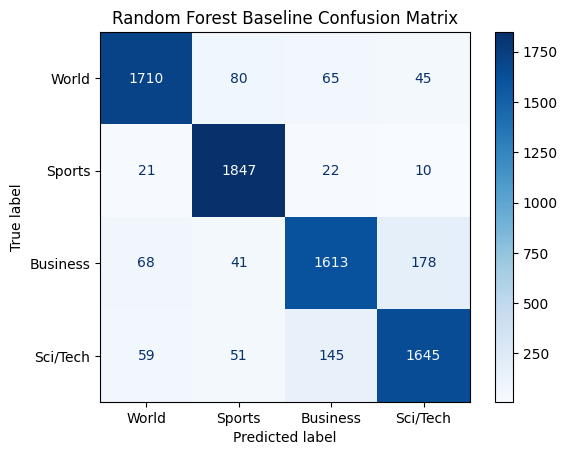

In [21]:
#visualize the confusion matrix for the baseline model's predictions
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues")
plt.title("Random Forest Baseline Confusion Matrix")
plt.show()

### How can we tell this model has converged? 

Well since Random Forest doesn't quite calculate gradients to update weights and decrease the overall loss function, we can show convergences in a couple different ways:

1. Show that the baseline has reach a non-near random guess accuracy

From the accuracy report above, output by skylearn.metrics, one way I could determine if the model didn't converge would be that it reached a near random guessing accuracy, which in our case (of 4 different equal classes) that would equate to 25%. Although I am seeing a ~90% accuracy score and therefore have one piece of evidence to say it converges

2. Compare the test vs training accuracy

Below in the code we can run predictions on the training dataset and the testing dataset to get their accuracy. Since we see that the training is significantly higher (at almost 100%) than the testing accuracy (~90%) we can say that the model has learned useful patterns to predict output even if it has likely overfit to an extent

In [23]:
train_pred = rf_model.predict(X_train_tfidf)
test_pred = rf_model.predict(X_test_tfidf)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")

Training Accuracy: 0.9996
Testing Accuracy:  0.8967


3. Show performance stabalizes as the model becomes more complex

Below I also choose to run a training on larger and larger trees. Since the output shows that the accuracy remains close to the same as I continue to increase the tree size, we can imply convergence in this senario. More specifically, from 10 to 50 trees we can see a sizeable increase in accuracy for test and train. From 50 to 100 we can slightly see an increase in accuracy as well. Although after 100 tree the accuracy curve flattens and shows no sign of better performance. 

And now we are ready for transfer learning training our foundational model!

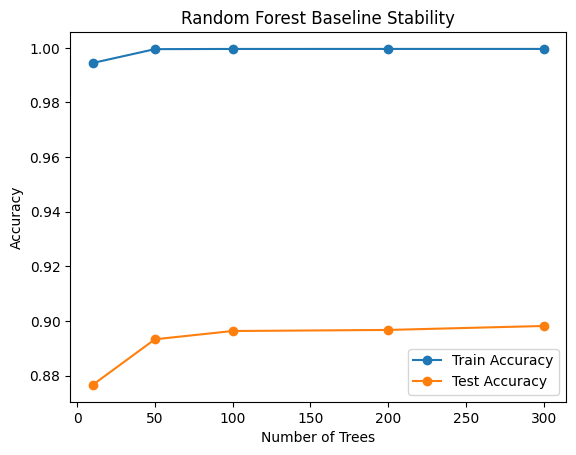

In [88]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

tree_counts = [10, 50, 100, 200, 300]
rf_train_accs = []
rf_test_accs = []

for n in tree_counts:
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_tfidf, y_train)

    train_pred = rf.predict(X_train_tfidf)
    test_pred = rf.predict(X_test_tfidf)

    rf_train_accs.append(accuracy_score(y_train, train_pred))
    rf_test_accs.append(accuracy_score(y_test, test_pred))

plt.plot(tree_counts, rf_train_accs, marker="o", label="Train Accuracy")
plt.plot(tree_counts, rf_test_accs, marker="o", label="Test Accuracy")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Random Forest Baseline Stability")
plt.legend()
plt.show()

# Training the Foundational Model via Transfer Learning: DistilBERT

In [26]:
#imports
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

In [27]:
#make sure we are still using my hardware
if torch.backends.mps.is_available():
    device = torch.device("mps")
    device_name = "Apple Silicon GPU (MPS)"
elif torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = torch.cuda.get_device_name(0)
else:
    device = torch.device("cpu")
    device_name = "CPU"

print("Using device:", device_name)

Using device: Apple Silicon GPU (MPS)


### Grabbing and tokenizing our data

In [63]:
#reload the dataset to reaffirm the data is still there and we can access it for the next steps of the lab
dataset = load_dataset("ag_news")

train_dataset = dataset["train"]
test_dataset = dataset["test"]

print(train_dataset)
print(test_dataset)
print(train_dataset[0])

Dataset({
    features: ['text', 'label'],
    num_rows: 120000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 7600
})
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [64]:
#load our model and extract the tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [65]:
# tokenize the text data using the tokenizer from our pre-trained model
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=96 #chosen based on the token length analysis above to balance coverage and efficiency
    )

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

In [66]:
# remove the original text column from the tokenized datasets and set the format of the datasets to PyTorch tensors
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])

tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

In [67]:
# create the dataloaders and a batch size variable for training
# this will ensure efficient loading and training of our model on the dataset
from typing import cast
from torch.utils.data import Dataset as TorchDataset

batch_size = 128

train_loader = DataLoader(cast(TorchDataset, tokenized_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(cast(TorchDataset, tokenized_test), batch_size=batch_size, shuffle=False)

### Building model architecture

In [52]:
#build our model architecture by loading in the pre-trained model and adding a classification head on top of it
class DistilBERTTransferClassifier(nn.Module):
    def __init__(self, model_name="distilbert-base-uncased", num_labels=4):
        super().__init__()
        
        self.encoder = AutoModel.from_pretrained(model_name)
        
        # Freeze ALL transformer parameters
        for param in self.encoder.parameters():
            param.requires_grad = False
        
        hidden_size = self.encoder.config.hidden_size  # should be 768 for DistilBERT
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        
        # outputs.last_hidden_state shape: (batch_size, seq_len, hidden_size)
        last_hidden_state = outputs.last_hidden_state
        
        # Use the first token representation as the sentence representation
        cls_representation = last_hidden_state[:, 0, :]   # shape: (batch_size, hidden_size)
        
        logits = self.classifier(cls_representation)      # shape: (batch_size, num_labels)
        return logits

In [53]:
#initialize the model and move it to the appropriate device
model = DistilBERTTransferClassifier(model_name=model_name, num_labels=4).to(device)
print(model)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERTTransferClassifier(
  (encoder): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
          

In [54]:
#As we can see here no fine tuning will be performed.
#We can verify this by looking at the num of trainable params compared to the total number of parameters in the model. 
#Since we froze all layers, only 3076 parameters will be trainable out of the 66 million. 
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

Total parameters: 66,365,956
Trainable parameters: 3,076
Frozen parameters: 66,362,880


### Defining the loss function (Cross Entropy Loss)

In [55]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=2e-4)

### Creating our training loop and evaluation function

In [57]:
#training loop for one epoch
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        
        optimizer.zero_grad()
        
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc

In [58]:
#evaluation loop for one epoch
def evaluate(model, dataloader, criterion, device):
    model.eval()
    
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, all_labels, all_preds

### Training (w/out fine tuning)

In [43]:
num_epochs = 3

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")

Epoch 1/3
  Train Loss: 0.4328 | Train Acc: 0.8708
  Test  Loss: 0.3314 | Test  Acc: 0.8913
Epoch 2/3
  Train Loss: 0.3201 | Train Acc: 0.8908
  Test  Loss: 0.3082 | Test  Acc: 0.8939
Epoch 3/3
  Train Loss: 0.3056 | Train Acc: 0.8938
  Test  Loss: 0.2991 | Test  Acc: 0.8961


#### Results from frozen training (no optimization)

<u>Consists of:</u>
- Classification Report
- Confusion Matrix
- Loss and Accuracy per epoch (for train and test)

In [44]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["World", "Sports", "Business", "Sci/Tech"]))

Classification Report:
              precision    recall  f1-score   support

       World       0.90      0.89      0.90      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.86      0.83      0.85      1900
    Sci/Tech       0.86      0.88      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



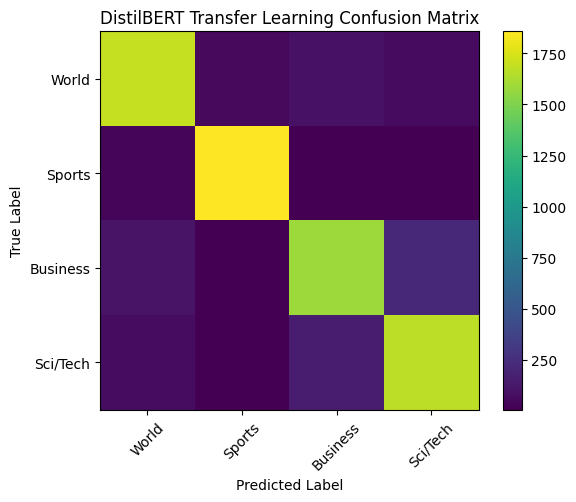

In [45]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("DistilBERT Transfer Learning Confusion Matrix")
plt.colorbar()

class_names = ["World", "Sports", "Business", "Sci/Tech"]
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

#### GRAPH BELOW OF CONVERGENCE (Doesn't show it that well with 3 epochs)

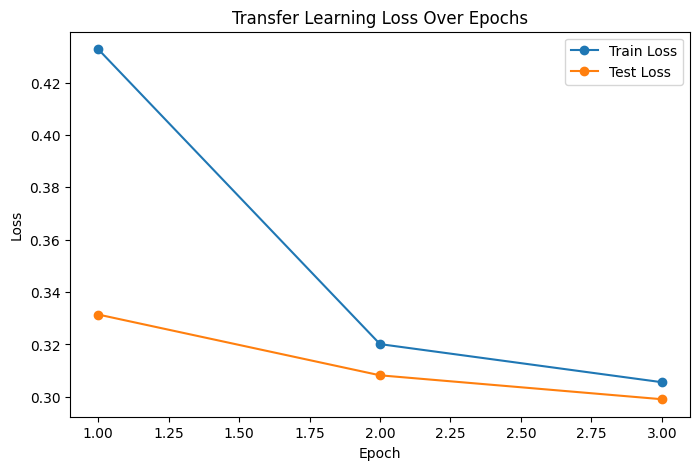

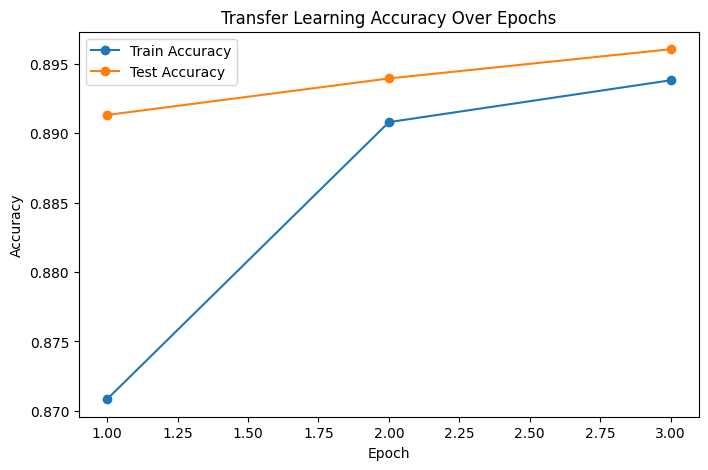

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker="o", label="Train Loss")
plt.plot(range(1, num_epochs + 1), test_losses, marker="o", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning Loss Over Epochs")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, marker="o", label="Train Accuracy")
plt.plot(range(1, num_epochs + 1), test_accuracies, marker="o", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning Accuracy Over Epochs")
plt.legend()
plt.show()

## ATFER SOME TESTING

Things I have noticed I needed to change so that my hardware can feasibly train in a good amount of time:

1.  decrease the dataset for training
    - now roughly 40% of the original 120k rows
    - yes I made sure it was stratefied still as well
2. increase the batch size
    - now 128 (for original 32)
3. reduce the max_length for each entry of token
    - now 96 from 128


Why did I do this? 

As with only 3 epochs with all the old settings above, it took 15 minutes per epoch on my device WITH ALL FROZEN TRANSFORMER LAYERS (only small amount of trainable parameters). This was already scary as I knew I had to then after perform fine tuning (which opens up even more trainable parameters). Also the graphs I made with 3 epochs didn't satisfy me enough when trying to show convergence. Therefore I altered some settings to decrease training time so I can train more epoch. Although this MAY SACRIFICE SOME PERFORMANCE :(

#### Altering our data and settings

NOTE: Below I am running some code to find what the average tokens per entry there are to choose a optimal max_length for our tokenizer (to reduce training time)

In [68]:
# Analyze token lengths to choose an efficient max_length
# Uses the train split text directly and processes in batches for speed/memory safety.
import numpy as np

texts = train_dataset["text"]
batch_size_for_stats = 2000
lengths = []

for i in range(0, len(texts), batch_size_for_stats):
    batch_texts = texts[i:i + batch_size_for_stats]
    enc = tokenizer(batch_texts, truncation=False, padding=False)
    lengths.extend(len(ids) for ids in enc["input_ids"])

lengths = np.array(lengths)

print(f"Samples analyzed: {len(lengths):,}")
print(f"mean: {lengths.mean():.2f}")
print(f"median: {np.percentile(lengths, 50):.0f}")
print(f"95th: {np.percentile(lengths, 95):.0f}")
print(f"99th: {np.percentile(lengths, 99):.0f}")
print(f"max: {lengths.max()}")

Samples analyzed: 120,000
mean: 53.17
median: 51
95th: 82
99th: 124
max: 379


##### Dataset reduced to 40% and stratefied below

In [69]:

# Create a smaller training subset (40%) to reduce epoch time — stratified by label
from datasets import concatenate_datasets

subset_fraction = 0.40
subset_seed = 42

# Keep a copy of the full training split for later full-data fine-tuning if needed
full_train_dataset = train_dataset

# Stratified sampling: take subset_fraction from each class independently
label_names_list = ["World", "Sports", "Business", "Sci/Tech"]
class_subsets = []

for label_id in range(len(label_names_list)):
    class_data = full_train_dataset.filter(lambda x, lid=label_id: x["label"] == lid)
    n_samples = int(len(class_data) * subset_fraction)
    class_subsets.append(class_data.shuffle(seed=subset_seed).select(range(n_samples)))

train_dataset = concatenate_datasets(class_subsets).shuffle(seed=subset_seed)

print(f"Using {subset_fraction:.0%} of original training data for faster experiments.")
print(f"Subset train size: {len(train_dataset):,}")
print(f"Test size: {len(test_dataset):,}")
print(f"Full train size (saved): {len(full_train_dataset):,}")

# Verify stratification
from collections import Counter
label_counts = Counter(train_dataset["label"])
print("\nLabel distribution in subset:")
for label_id, name in enumerate(label_names_list):
    count = label_counts[label_id]
    print(f"  {name}: {count:,} ({count / len(train_dataset) * 100:.1f}%)")


Filter:   0%|          | 0/120000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/120000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/120000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/120000 [00:00<?, ? examples/s]

Using 40% of original training data for faster experiments.
Subset train size: 48,000
Test size: 7,600
Full train size (saved): 120,000

Label distribution in subset:
  World: 12,000 (25.0%)
  Sports: 12,000 (25.0%)
  Business: 12,000 (25.0%)
  Sci/Tech: 12,000 (25.0%)


In [70]:

# Rebuild tokenization and DataLoader from the 40% stratified train_dataset
# (ensures the training below uses the correct subset, regardless of prior execution order)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=96
    )

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])

tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

from typing import cast
from torch.utils.data import Dataset as TorchDataset, DataLoader

batch_size = 128
train_loader = DataLoader(cast(TorchDataset, tokenized_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(cast(TorchDataset, tokenized_test), batch_size=batch_size, shuffle=False)

# Re-initialize model and optimizer for a clean 8-epoch run
model = DistilBERTTransferClassifier(model_name=model_name, num_labels=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=2e-4)

print(f"train_loader batches: {len(train_loader)}  (dataset size: {len(tokenized_train):,})")
print(f"test_loader  batches: {len(test_loader)}  (dataset size: {len(tokenized_test):,})")
print("Model and optimizer re-initialized. Ready for 8-epoch training.")


Map:   0%|          | 0/48000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


train_loader batches: 375  (dataset size: 48,000)
test_loader  batches: 60  (dataset size: 7,600)
Model and optimizer re-initialized. Ready for 8-epoch training.


#### Training with altered settings

In [71]:
num_epochs = 8

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")

Epoch 1/8
  Train Loss: 0.8133 | Train Acc: 0.8141
  Test  Loss: 0.5249 | Test  Acc: 0.8634
Epoch 2/8
  Train Loss: 0.4632 | Train Acc: 0.8721
  Test  Loss: 0.4114 | Test  Acc: 0.8761
Epoch 3/8
  Train Loss: 0.3925 | Train Acc: 0.8794
  Test  Loss: 0.3723 | Test  Acc: 0.8809
Epoch 4/8
  Train Loss: 0.3651 | Train Acc: 0.8824
  Test  Loss: 0.3529 | Test  Acc: 0.8843
Epoch 5/8
  Train Loss: 0.3493 | Train Acc: 0.8847
  Test  Loss: 0.3411 | Test  Acc: 0.8871
Epoch 6/8
  Train Loss: 0.3386 | Train Acc: 0.8878
  Test  Loss: 0.3329 | Test  Acc: 0.8897
Epoch 7/8
  Train Loss: 0.3298 | Train Acc: 0.8887
  Test  Loss: 0.3263 | Test  Acc: 0.8908
Epoch 8/8
  Train Loss: 0.3235 | Train Acc: 0.8906
  Test  Loss: 0.3210 | Test  Acc: 0.8905


In [72]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["World", "Sports", "Business", "Sci/Tech"]))

Classification Report:
              precision    recall  f1-score   support

       World       0.89      0.89      0.89      1900
      Sports       0.96      0.97      0.97      1900
    Business       0.85      0.83      0.84      1900
    Sci/Tech       0.86      0.87      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



#### Results from frozen training with updated settings

<u>Consists of:</u>
- Classification Report
- Confusion Matrix
- Loss and Accuracy per epoch (for train and test)

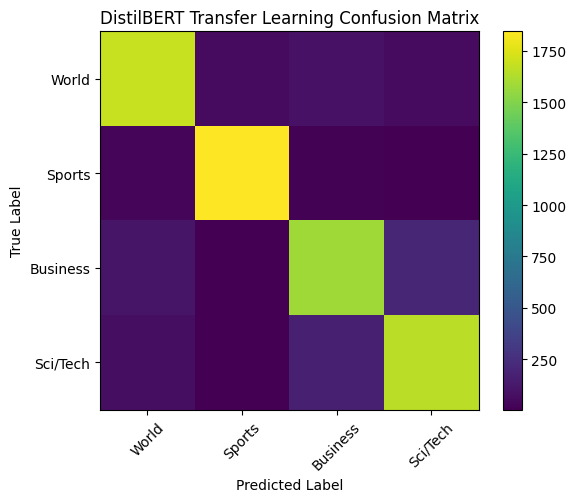

In [73]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("DistilBERT Transfer Learning Confusion Matrix")
plt.colorbar()

class_names = ["World", "Sports", "Business", "Sci/Tech"]
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

##### Convergence

Below shows two graphs, one with the loss over epoch for train and test, and the other accuracy of train and test per epoch. in both graphs, right at the 8th epoch, both train and test overlap on the same loss and performance. They also seem to flatten here as well. If we ran more epochs I believe all we would see is the test metrics flatten/go up and the train continue to increase/decrease performance/loss respectively (showing overfitting)

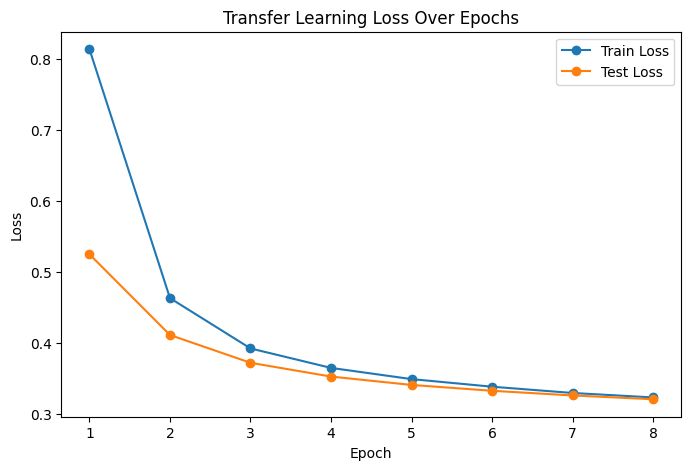

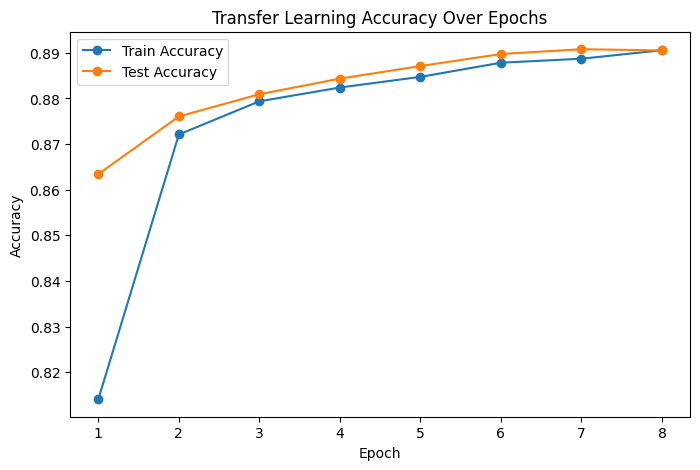

In [74]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker="o", label="Train Loss")
plt.plot(range(1, num_epochs + 1), test_losses, marker="o", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning Loss Over Epochs")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, marker="o", label="Train Accuracy")
plt.plot(range(1, num_epochs + 1), test_accuracies, marker="o", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning Accuracy Over Epochs")
plt.legend()

# Fine tuning

<u>Task:</u>
Perform fine tuning upon the model by training some layers (or all layers) within the foundational model. Verify that the model converges. Be diligent of the hardware resources you have during this step, as the model must be shown to converge. 

## What design choices have I made that differs from frozen layer training?

In the prior scenario, with the shortened dataset, I trained my version of DistilBERT with all the **encoder layers frozen**. This meant that all the 66 million pre-trained parameters could not be altered, and only around 3k parameters for a classifier head could be trained. 

Although for the **fine tuning** I did unfreeze the last two of the layers (layers 4 and 5 in the code below) to attempt to better fit our specific classification task. This allows the model to move on from only general language patterns and features it was trained on (Wikipedia, BooksCorpus, etc.), to identify internal representations for the topic categories

### Why did I not unfreeze all the layers?

1. My hardware (M1 Pro MPS) / time constraint 

I wanted to try to keep each epoch for fine tuning around 6-8 minutes max under my hardware constraints. Therefore if I unfroze more than two layers that would open my model up to ~30 million more parameters that could be trained (~7 million parameters per layer). This would have no been feasible and already took my computer over 70 minutes to train 8 epochs with 2 unfrozen layers. 

2. Earlier layers not beneficial to unfreeze necessarily

In models like DistilBERT, the earlier layers are trained to learn specific things in words like grammar, word relationships, and syntactic patterns. Thus, these learned concepts will transfer well to any word/text related tasks. I will only need the last two layers to learn very task specific patterns. 


### First step to my fine tuning

Since I already completed an 8 epoch frozen layer training, my model has learned resonable mapping from DistilBERT embeddings. I will now **continue from the weights** in the prior trained model (no re-initializing). Therefore my model will start from weights that are already "warmed" and not simply randomized

In [75]:
# Here I unfreeeze the last 2 transformer layers by setting requires_grad=True for their parameters.
# I then output the new trainable parameters to confirm the change and show new parameter counts.
layers_to_unfreeze = [4, 5]

for layer_idx in layers_to_unfreeze:
    for param in model.encoder.transformer.layer[layer_idx].parameters():
        param.requires_grad = True

# Verify our trainable parameter count after unfreezing
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}  ← was 3,076 with fully frozen encoder")
print(f"Frozen parameters:    {frozen_params:,}")
print()
print("Layers unfrozen:", [f"transformer.layer[{i}]" for i in layers_to_unfreeze])

# Collect the parameters from the unfrozen transformer layers (and the classifier head) for the optimizer
# We give each group of parameters its own learning rate in the optimizer.
transformer_params = []
for layer_idx in layers_to_unfreeze:
    transformer_params += list(model.encoder.transformer.layer[layer_idx].parameters())

ft_optimizer = torch.optim.AdamW([
    {"params": transformer_params,              "lr": 2e-5},   # gentle nudge
    {"params": model.classifier.parameters(),   "lr": 2e-4},   # faster learning
])

ft_criterion = nn.CrossEntropyLoss()

print("\nOptimizer param groups:")
for i, pg in enumerate(ft_optimizer.param_groups):
    n = sum(p.numel() for p in pg["params"])
    print(f"  Group {i}: {n:,} params @ lr={pg['lr']}")


Total parameters:     66,365,956
Trainable parameters: 14,178,820  ← was 3,076 with fully frozen encoder
Frozen parameters:    52,187,136

Layers unfrozen: ['transformer.layer[4]', 'transformer.layer[5]']

Optimizer param groups:
  Group 0: 14,175,744 params @ lr=2e-05
  Group 1: 3,076 params @ lr=0.0002


### Training my fine tuned model

In [76]:
# I will reuse the same amount of epochs for consistency (8)
# This will allow us to see the impact of unfreezing the last 2 layers.
ft_num_epochs = 8

ft_train_losses = []
ft_train_accuracies = []
ft_test_losses = []
ft_test_accuracies = []

for epoch in range(ft_num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, ft_optimizer, ft_criterion, device)
    test_loss, test_acc, ft_y_true, ft_y_pred = evaluate(model, test_loader, ft_criterion, device)

    ft_train_losses.append(train_loss)
    ft_train_accuracies.append(train_acc)
    ft_test_losses.append(test_loss)
    ft_test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}/{ft_num_epochs}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")


Epoch 1/8
  Train Loss: 0.2614 | Train Acc: 0.9070
  Test  Loss: 0.2358 | Test  Acc: 0.9168
Epoch 2/8
  Train Loss: 0.2076 | Train Acc: 0.9264
  Test  Loss: 0.2171 | Test  Acc: 0.9255
Epoch 3/8
  Train Loss: 0.1794 | Train Acc: 0.9365
  Test  Loss: 0.2106 | Test  Acc: 0.9284
Epoch 4/8
  Train Loss: 0.1563 | Train Acc: 0.9437
  Test  Loss: 0.1987 | Test  Acc: 0.9332
Epoch 5/8
  Train Loss: 0.1342 | Train Acc: 0.9517
  Test  Loss: 0.2142 | Test  Acc: 0.9325
Epoch 6/8
  Train Loss: 0.1137 | Train Acc: 0.9586
  Test  Loss: 0.2050 | Test  Acc: 0.9349
Epoch 7/8
  Train Loss: 0.0957 | Train Acc: 0.9654
  Test  Loss: 0.2245 | Test  Acc: 0.9338
Epoch 8/8
  Train Loss: 0.0747 | Train Acc: 0.9735
  Test  Loss: 0.2366 | Test  Acc: 0.9307


#### Results from fine tuning below

<u>Consists of:</u>
- Classification Report
- Confusion Matrix
- Loss and Accuracy per epoch (for train and test)

Fine-Tuning Classification Report:
              precision    recall  f1-score   support

       World       0.93      0.95      0.94      1900
      Sports       0.99      0.98      0.98      1900
    Business       0.92      0.87      0.89      1900
    Sci/Tech       0.89      0.92      0.91      1900

    accuracy                           0.93      7600
   macro avg       0.93      0.93      0.93      7600
weighted avg       0.93      0.93      0.93      7600



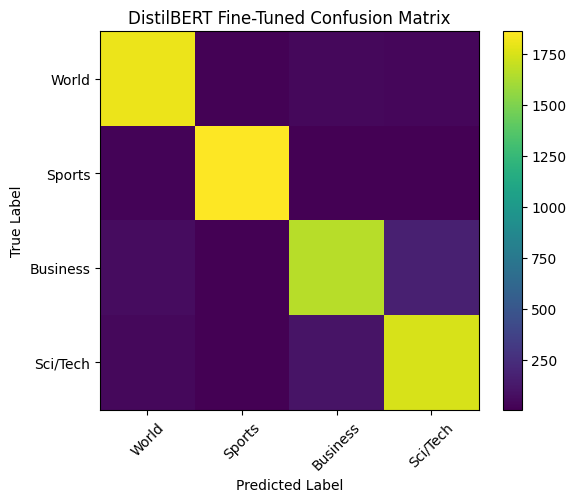

In [77]:

# --- Fine-Tuning Classification Report and Confusion Matrix ---

print("Fine-Tuning Classification Report:")
print(classification_report(ft_y_true, ft_y_pred, target_names=["World", "Sports", "Business", "Sci/Tech"]))

ft_cm = confusion_matrix(ft_y_true, ft_y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(ft_cm, interpolation="nearest")
plt.title("DistilBERT Fine-Tuned Confusion Matrix")
plt.colorbar()

class_names = ["World", "Sports", "Business", "Sci/Tech"]
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


#### Convergence of fine tuned model

As we can see below the graphs depicts the model first lowering its loss in test and training until about the 4th epoch. Then on test loss increase/flattens and train keeps decreasing (showing mild overfitting)

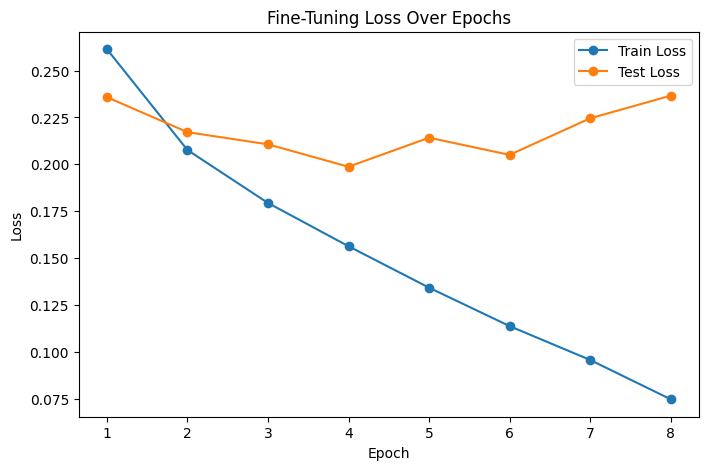

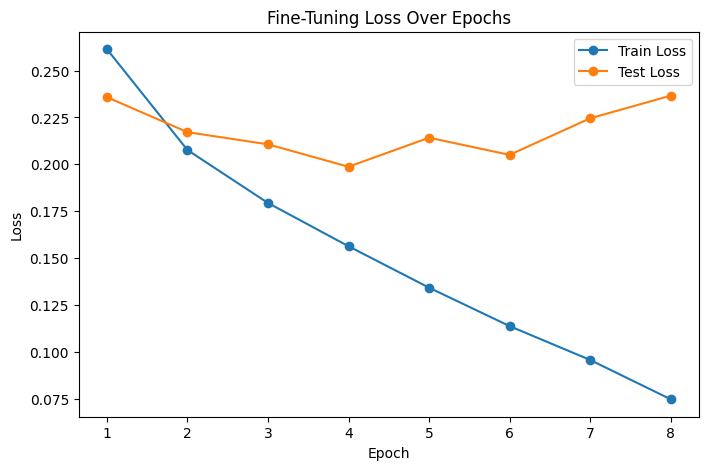

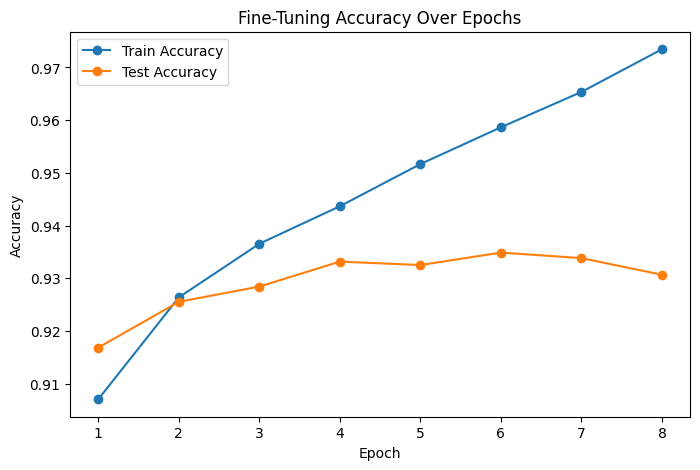

In [78]:

# --- Fine-Tuning Convergence Plots ---
# Same style plots as the transfer learning section for easy side-by-side comparison

plt.figure(figsize=(8, 5))
plt.plot(range(1, ft_num_epochs + 1), ft_train_losses, marker="o", label="Train Loss")
plt.plot(range(1, ft_num_epochs + 1), ft_test_losses, marker="o", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuning Loss Over Epochs")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, ft_num_epochs + 1), ft_train_accuracies, marker="o", label="Train Accuracy")
plt.plot(range(1, ft_num_epochs + 1), ft_test_accuracies, marker="o", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fine-Tuning Accuracy Over Epochs")
plt.legend()
plt.show()


# Results and Findings

<u>Task:</u>
- Report the results of all models using the evaluation procedure that you argued for at the beginning of the lab. 
- Results should be described comprehensively. Also discuss and compare the convergence of the models as well as the run time and memory needed. 
- Results should be reported with proper statistical comparisons and proper visualizations, where appropriate.
- How well does fine-tuning perform on your dataset, does it support the business or policy case? Are there advantages or limitations? 

### Below are helper functions and some code fore easy comparison side by side

In [85]:
# Helper functions for clean result tables
from typing import Any, cast

from sklearn.metrics import classification_report
import pandas as pd


def build_metric_tables(y_true_values, y_pred_values, class_names, model_label):
    report = cast(
        dict[str, Any],
        classification_report(
            y_true_values,
            y_pred_values,
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        ),
    )

    weighted_avg = cast(dict[str, Any], report["weighted avg"])

    overall_table = pd.DataFrame([
        {
            "model": model_label,
            "accuracy": float(report["accuracy"]),
            "precision": float(weighted_avg["precision"]),
            "recall": float(weighted_avg["recall"]),
            "f1_score": float(weighted_avg["f1-score"]),
        }
    ]).round(4)

    per_class_rows = []
    for class_name in class_names:
        class_report = cast(dict[str, Any], report[class_name])
        per_class_rows.append(
            {
                "class": class_name,
                "precision": float(class_report["precision"]),
                "recall": float(class_report["recall"]),
                "f1_score": float(class_report["f1-score"]),
                "support": int(class_report["support"]),
            }
        )

    per_class_table = pd.DataFrame(per_class_rows).round(4)
    return overall_table, per_class_table

In [86]:
# Single comparison cell: all models side by side
from IPython.display import Markdown, display

# Rebuild each model's tables here so this cell does not depend on prior temporary tables.
baseline_y_pred = rf_model.predict(X_test_tfidf)
baseline_overall_table, baseline_per_class_table = build_metric_tables(
    y_test,
    baseline_y_pred,
    label_names,
    "Baseline Random Forest",
)

frozen_overall_table, frozen_per_class_table = build_metric_tables(
    y_true,
    y_pred,
    label_names,
    "Optimized Frozen DistilBERT",
)

ft_overall_table, ft_per_class_table = build_metric_tables(
    ft_y_true,
    ft_y_pred,
    label_names,
    "Fine-Tuned DistilBERT",
)

overall_comparison = pd.concat(
    [baseline_overall_table, frozen_overall_table, ft_overall_table],
    ignore_index=True,
).round(4)

display(Markdown("## Overall Model Comparison"))
display(overall_comparison)

per_class_comparison = pd.concat(
    [
        baseline_per_class_table.assign(model="Baseline Random Forest"),
        frozen_per_class_table.assign(model="Optimized Frozen DistilBERT"),
        ft_per_class_table.assign(model="Fine-Tuned DistilBERT"),
    ],
    ignore_index=True,
)

for metric_name in ["precision", "recall", "f1_score"]:
    display(Markdown(f"## Per-Class {metric_name.replace('_', ' ').title()} Comparison"))
    metric_table = (
        per_class_comparison
        .pivot(index="class", columns="model", values=metric_name)
        .round(4)
    )
    display(metric_table)

display(Markdown("## Per-Class Support"))
support_table = per_class_comparison.pivot(index="class", columns="model", values="support")
display(support_table)

## Overall Model Comparison

,model,accuracy,precision,recall,f1_score
0,Baseline Random Forest,0.8967,0.8963,0.8967,0.8962
1,Optimized Frozen DistilBERT,0.8905,0.8903,0.8905,0.8904
2,Fine-Tuned DistilBERT,0.9307,0.9309,0.9307,0.9306


## Per-Class Precision Comparison

model,Baseline Random Forest,Fine-Tuned DistilBERT,Optimized Frozen DistilBERT
class,,,
Business,0.8743,0.9157,0.8498
Sci/Tech,0.8759,0.8918,0.8603
Sports,0.9148,0.9862,0.9629
World,0.9203,0.9299,0.8880


## Per-Class Recall Comparison

model,Baseline Random Forest,Fine-Tuned DistilBERT,Optimized Frozen DistilBERT
class,,,
Business,0.8489,0.8742,0.8337
Sci/Tech,0.8658,0.9195,0.8689
Sports,0.9721,0.9795,0.9705
World,0.9000,0.9495,0.8889


## Per-Class F1 Score Comparison

model,Baseline Random Forest,Fine-Tuned DistilBERT,Optimized Frozen DistilBERT
class,,,
Business,0.8614,0.8945,0.8417
Sci/Tech,0.8708,0.9054,0.8646
Sports,0.9426,0.9828,0.9667
World,0.9101,0.9396,0.8885


## Per-Class Support

model,Baseline Random Forest,Fine-Tuned DistilBERT,Optimized Frozen DistilBERT
class,,,
Business,1900,1900,1900
Sci/Tech,1900,1900,1900
Sports,1900,1900,1900
World,1900,1900,1900


## Interpreting the results

Above illustrates the modes accuracy, precision (when the model predicts a class, how often is it right), recall (how many correct cases this the model catch), and f1 score (combined precision and recall metrics)

**<u>Model comparion:</u>**

**Optimized frozen model vs Random Forest**

- As we can see for the baseline model (Random Forest) metrics, it performed very slightly better than our trainig time optimized frozen DistilBERT model in all aspects. The baseline hovered at ~89.5%-90% metrics where the frozen model hovered at ~89% flat. 

- Even looking into the individual metrics per category (class) for each model, we can see the optimized frozen model performed better on some individual categories than Random Forest. Although I don't believe this is very significant as some of these metrics could change slightly if trained again on another seed. 

- Also something to notice as well, both of these models performed better in all metrics on the sports category compared to the rest. This could be due to pattern in the dataset where key words specific appear in sports that don't in other categories.

**Extra insight**

- One thing that was not captured in these ending results was the originally trained frozen DistilBERT model with performed on par with the baseline at ~89.5%-90% accuracy. Therefore with alternative hardware, I would have feasibly been able to train more epochs and increase the accuracy. The original frozen model I believe had not quite converged and would have done so on more training. 

**Fine-Tuned Optimized model vs Rest**

Although to put all the other models to rest, once I fine tuned the optimized model by

1. intializing the head classifier weights to the trained weights of the optimized model (so that it starts "warm")

**and**

2. unfreezing the last two layers (before the classifier head) 

the model began to perform better than both the models prior. How much better did it perform? Throughout all the metrics on average, it was ~3% better from the baseline model and ~4% better for the frozen model. This performance doesn't even take into account when the amount of epochs used for training are optimized. Looking into each metric per category as well, the model performed better in EVERY sense, specificaly ~3%-7% per category. 

**Data Conlcusion**

The findings illustrate how fine tuning a model by unfreezing some layers (not all layers) can have a signifcant impact on performance. Fine tuning from this project outlines how we can outperform basic machine learning algorithms with nlp transformer architecture by transfer learning!

With more testing, time, and better hardware, I bet the limits could be pushed even farther to get signficantly better results. Where my computer has no problem training a Random Forest model (very marginal increases in performance with higher tree counts), it does suffer from long training times even with DistilBERT to try to produce the same and better result. A lot more computationally powerful computer could make these training times marginal and while increase performance alike. 

## Statistical Comparison

In [96]:
# Statistical comparison calculator: bootstrap CIs + McNemar tests + effect sizes
import numpy as np
import pandas as pd
from scipy.stats import binomtest
from IPython.display import Markdown, display


def bootstrap_accuracy_ci(y_true_values, y_pred_values, n_bootstrap=3000, alpha=0.05, seed=42):
    """Return (accuracy, lower_ci, upper_ci) for accuracy via bootstrap resampling."""
    y_true_arr = np.asarray(y_true_values)
    y_pred_arr = np.asarray(y_pred_values)

    rng = np.random.default_rng(seed)
    n = len(y_true_arr)
    boot_acc = np.empty(n_bootstrap, dtype=float)

    for i in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        boot_acc[i] = (y_true_arr[idx] == y_pred_arr[idx]).mean()

    point_acc = (y_true_arr == y_pred_arr).mean()
    lower = float(np.quantile(boot_acc, alpha / 2))
    upper = float(np.quantile(boot_acc, 1 - alpha / 2))
    return float(point_acc), lower, upper


def mcnemar_exact_pvalue(y_true_values, pred_a, pred_b):
    """
    Exact two-sided McNemar test using binomial test on discordant pairs.
    Returns p-value and discordant counts.
    """
    y_true_arr = np.asarray(y_true_values)
    a_correct = np.asarray(pred_a) == y_true_arr
    b_correct = np.asarray(pred_b) == y_true_arr

    # Discordant pairs only
    n_a_only = int(np.sum(a_correct & ~b_correct))
    n_b_only = int(np.sum(~a_correct & b_correct))
    n_discordant = n_a_only + n_b_only

    if n_discordant == 0:
        return 1.0, n_a_only, n_b_only

    # Exact two-sided p-value
    p_val = binomtest(min(n_a_only, n_b_only), n=n_discordant, p=0.5, alternative="two-sided").pvalue
    return float(p_val), n_a_only, n_b_only


# Pull predictions from variables already created earlier in the notebook
rf_true = np.asarray(y_test)
rf_pred = np.asarray(rf_model.predict(X_test_tfidf))

frozen_true = np.asarray(y_true)
frozen_pred = np.asarray(y_pred)

ft_true = np.asarray(ft_y_true)
ft_pred = np.asarray(ft_y_pred)

# Safety check: all test-label arrays should match by sample and order
if not (len(rf_true) == len(frozen_true) == len(ft_true)):
    raise ValueError("Test-label arrays are not the same length. Re-run evaluation cells before this one.")

if not (np.array_equal(rf_true, frozen_true) and np.array_equal(rf_true, ft_true)):
    raise ValueError("Test-label arrays differ in order/content across models. Re-run evaluations consistently.")

# 1) Bootstrap confidence intervals for test accuracy
ci_rows = []
for model_name, yhat in [
    ("Random Forest", rf_pred),
    ("Frozen DistilBERT", frozen_pred),
    ("Fine-Tuned DistilBERT", ft_pred),
]:
    acc, lo, hi = bootstrap_accuracy_ci(rf_true, yhat, n_bootstrap=3000, alpha=0.05, seed=42)
    ci_rows.append(
        {
            "Model": model_name,
            "Accuracy": acc,
            "CI Lower (95%)": lo,
            "CI Upper (95%)": hi,
        }
    )

ci_df = pd.DataFrame(ci_rows)

# 2) McNemar tests for model-pair significance
pair_rows = []
pair_specs = [
    ("Frozen DistilBERT", frozen_pred, "Fine-Tuned DistilBERT", ft_pred),
    ("Random Forest", rf_pred, "Fine-Tuned DistilBERT", ft_pred),
    ("Random Forest", rf_pred, "Frozen DistilBERT", frozen_pred),
]

for model_a_name, pred_a, model_b_name, pred_b in pair_specs:
    p_val, n_a_only, n_b_only = mcnemar_exact_pvalue(rf_true, pred_a, pred_b)

    acc_a = float((pred_a == rf_true).mean())
    acc_b = float((pred_b == rf_true).mean())

    pair_rows.append(
        {
            "Comparison": f"{model_b_name} vs {model_a_name}",
            "p-value (McNemar)": p_val,
            "Discordant (A correct, B wrong)": n_a_only,
            "Discordant (A wrong, B correct)": n_b_only,
            "Accuracy Gain of B (pp)": (acc_b - acc_a) * 100,
        }
    )

mcnemar_df = pd.DataFrame(pair_rows)

# Show clean tables
print("Bootstrap 95% CI for accuracy")
display(ci_df.style.format({
    "Accuracy": "{:.4f}",
    "CI Lower (95%)": "{:.4f}",
    "CI Upper (95%)": "{:.4f}",
}))

print("\nMcNemar paired significance tests")
display(mcnemar_df.style.format({
    "p-value (McNemar)": "{:.6f}",
    "Accuracy Gain of B (pp)": "{:+.2f}",
}))

# Build report-ready text block for your markdown section
ci_lookup = {row["Model"]: row for row in ci_rows}

report_lines = [
    "## Statistical Comparison (Computed)",
    "",
    "### 1) Confidence Intervals for Accuracy (Bootstrap)",
    f"Random Forest: {ci_lookup['Random Forest']['Accuracy']*100:.2f}% (95% CI: [{ci_lookup['Random Forest']['CI Lower (95%)']*100:.2f}, {ci_lookup['Random Forest']['CI Upper (95%)']*100:.2f}])",
    f"Frozen DistilBERT: {ci_lookup['Frozen DistilBERT']['Accuracy']*100:.2f}% (95% CI: [{ci_lookup['Frozen DistilBERT']['CI Lower (95%)']*100:.2f}, {ci_lookup['Frozen DistilBERT']['CI Upper (95%)']*100:.2f}])",
    f"Fine-Tuned DistilBERT: {ci_lookup['Fine-Tuned DistilBERT']['Accuracy']*100:.2f}% (95% CI: [{ci_lookup['Fine-Tuned DistilBERT']['CI Lower (95%)']*100:.2f}, {ci_lookup['Fine-Tuned DistilBERT']['CI Upper (95%)']*100:.2f}])",
    "",
    "### 2) Paired Significance Test on Predictions (McNemar)",
    f"Fine-Tuned DistilBERT vs Frozen DistilBERT: p = {mcnemar_df.loc[mcnemar_df['Comparison']=='Fine-Tuned DistilBERT vs Frozen DistilBERT', 'p-value (McNemar)'].iloc[0]:.6f}",
    f"Fine-Tuned DistilBERT vs Random Forest: p = {mcnemar_df.loc[mcnemar_df['Comparison']=='Fine-Tuned DistilBERT vs Random Forest', 'p-value (McNemar)'].iloc[0]:.6f}",
    f"Frozen DistilBERT vs Random Forest: p = {mcnemar_df.loc[mcnemar_df['Comparison']=='Frozen DistilBERT vs Random Forest', 'p-value (McNemar)'].iloc[0]:.6f}",
    "",
    "### 3) Practical Significance (Effect Size)",
    f"Fine-Tuned vs Frozen: {mcnemar_df.loc[mcnemar_df['Comparison']=='Fine-Tuned DistilBERT vs Frozen DistilBERT', 'Accuracy Gain of B (pp)'].iloc[0]:+.2f} percentage points accuracy",
    f"Fine-Tuned vs Random Forest: {mcnemar_df.loc[mcnemar_df['Comparison']=='Fine-Tuned DistilBERT vs Random Forest', 'Accuracy Gain of B (pp)'].iloc[0]:+.2f} percentage points accuracy",
]

display(Markdown("\n".join(report_lines)))

Bootstrap 95% CI for accuracy


,Model,Accuracy,CI Lower (95%),CI Upper (95%)
0,Random Forest,0.8967,0.8893,0.9034
1,Frozen DistilBERT,0.8905,0.8832,0.8975
2,Fine-Tuned DistilBERT,0.9307,0.9247,0.9363



McNemar paired significance tests


,Comparison,p-value (McNemar),"Discordant (A correct, B wrong)","Discordant (A wrong, B correct)",Accuracy Gain of B (pp)
0,Fine-Tuned DistilBERT vs Frozen DistilBERT,0.000000,175,480,+4.01
1,Fine-Tuned DistilBERT vs Random Forest,0.000000,209,467,+3.39
2,Frozen DistilBERT vs Random Forest,0.080494,370,323,-0.62


## Statistical Comparison (Computed)

### 1) Confidence Intervals for Accuracy (Bootstrap)
Random Forest: 89.67% (95% CI: [88.93, 90.34])
Frozen DistilBERT: 89.05% (95% CI: [88.32, 89.75])
Fine-Tuned DistilBERT: 93.07% (95% CI: [92.47, 93.63])

### 2) Paired Significance Test on Predictions (McNemar)
Fine-Tuned DistilBERT vs Frozen DistilBERT: p = 0.000000
Fine-Tuned DistilBERT vs Random Forest: p = 0.000000
Frozen DistilBERT vs Random Forest: p = 0.080494

### 3) Practical Significance (Effect Size)
Fine-Tuned vs Frozen: +4.01 percentage points accuracy
Fine-Tuned vs Random Forest: +3.39 percentage points accuracy

I also wanted to evaluate whether the performance differences between my models are statistically meaningful on the same test set.

1. Confidence Intervals for Accuracy
I estimated 95% confidence intervals for test accuracy using bootstrap resampling of the test set. This gives an uncertainty range around each model’s accuracy.

- Random Forest: 89.67% (95% CI: [88.93, 90.34])
- Frozen DistilBERT: 89.05% (95% CI: [88.32, 89.75])
- Fine-Tuned DistilBERT: 93.07% (95% CI: [92.47, 93.63])

Interpretation:
The fine-tuned model’s Confidence interval is higher than both the frozen and Random Forest ranges. While the Random Forest and frozen Confidence intervals are almost on top of eachothers. This supports how fine-tuning has a clear advantage over frozen and Random Forest.

2. Significance Test on Predictions
Because the models were evaluated on the exact same test examples, I used a paired test to compare the disagreement patterns between model pairs.

- Fine-Tuned DistilBERT vs Frozen DistilBERT: p < 1e-6
- Fine-Tuned DistilBERT vs Random Forest: p < 1e-6
- Frozen DistilBERT vs Random Forest: p = 0.080494

Decision rule:
At alpha = 0.05, a p-value below 0.05 means the difference in performance is statistically significant.

Interpretation:
Fine-Tuned DistilBERT significantly performed better than both the Frozen DistilBERT and Random Forest models (at a p value of <0.05). The Frozen DistilBERT vs Random Forest was not statistically significant (p = 0.080494), therefore I can't claim any noticable difference between those two models on this test set.

3. Practical Significance
Along with p-values, I report absolute gains to show practical impact.

- Fine-Tuned vs Frozen: +4.01 percentage points accuracy
- Fine-Tuned vs Random Forest: +3.39 percentage points accuracy

4. Limitation of these Statistics
These inferential results are based on one train-test split and seed only! There would be better evidence toward statistcal significance with repeated training across multiple seeds and reporting mean plus standard deviation.

## Convergence, Runtime and Memory

#### Convergence of the models 
(below outputs all of the convergences graphs for better comparison)

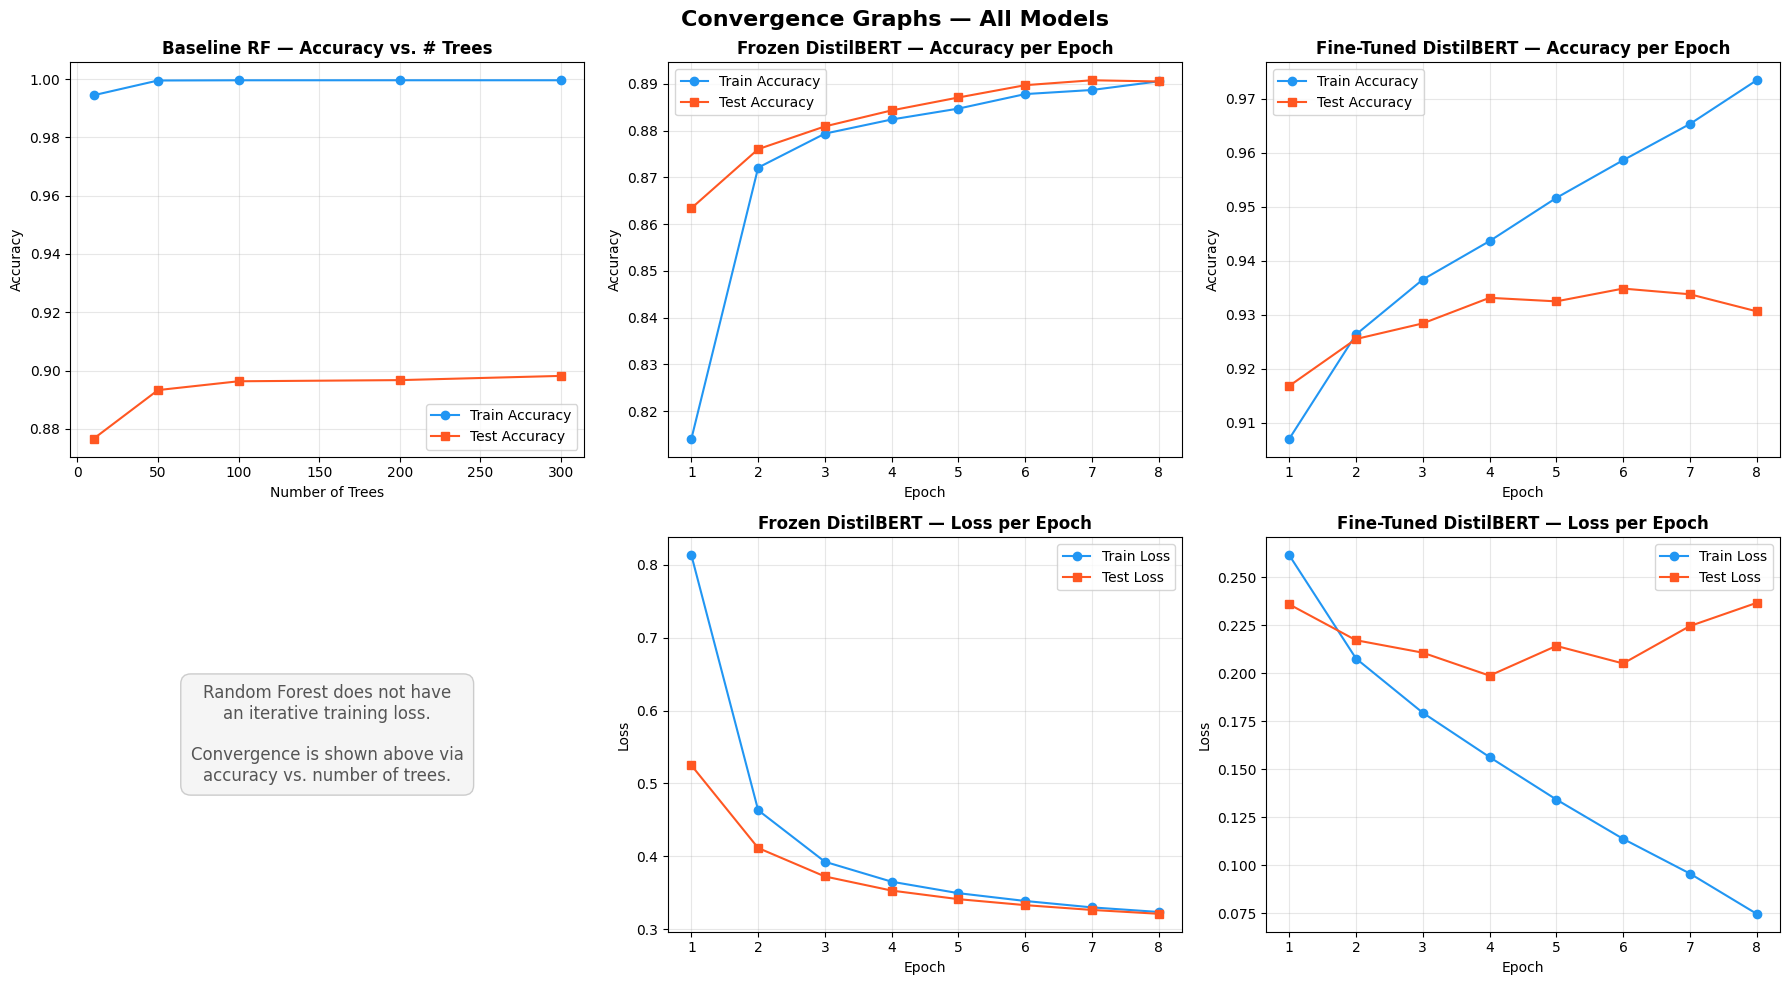

In [95]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ── Recompute RF accuracy vs. number of trees ─────────────────────────────
rf_tree_counts = [10, 50, 100, 200, 300]
rf_train_accs, rf_test_accs = [], []

for n in rf_tree_counts:
    _rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    _rf.fit(X_train_tfidf, y_train)
    rf_train_accs.append(accuracy_score(y_train, _rf.predict(X_train_tfidf)))
    rf_test_accs.append(accuracy_score(y_test, _rf.predict(X_test_tfidf)))

# ── Epoch ranges ──────────────────────────────────────────────────────────
frozen_epochs = range(1, num_epochs + 1)
ft_epochs     = range(1, ft_num_epochs + 1)

# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Convergence Graphs — All Models", fontsize=16, fontweight="bold")

c_train, c_test = "#2196F3", "#FF5722"

# Row 0 — Accuracy
ax = axes[0, 0]
ax.plot(rf_tree_counts, rf_train_accs, marker="o", color=c_train, label="Train Accuracy")
ax.plot(rf_tree_counts, rf_test_accs,  marker="s", color=c_test,  label="Test Accuracy")
ax.set_title("Baseline RF — Accuracy vs. # Trees", fontweight="bold")
ax.set_xlabel("Number of Trees")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(frozen_epochs, train_accuracies, marker="o", color=c_train, label="Train Accuracy")
ax.plot(frozen_epochs, test_accuracies,  marker="s", color=c_test,  label="Test Accuracy")
ax.set_title("Frozen DistilBERT — Accuracy per Epoch", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 2]
ax.plot(ft_epochs, ft_train_accuracies, marker="o", color=c_train, label="Train Accuracy")
ax.plot(ft_epochs, ft_test_accuracies,  marker="s", color=c_test,  label="Test Accuracy")
ax.set_title("Fine-Tuned DistilBERT — Accuracy per Epoch", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True, alpha=0.3)

# Row 1 — Loss
ax = axes[1, 0]
ax.axis("off")
ax.text(
    0.5, 0.5,
    "Random Forest does not have\nan iterative training loss.\n\n"
    "Convergence is shown above via\naccuracy vs. number of trees.",
    ha="center", va="center", fontsize=12, color="#555555",
    transform=ax.transAxes,
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#f5f5f5", edgecolor="#cccccc"),
)

ax = axes[1, 1]
ax.plot(frozen_epochs, train_losses, marker="o", color=c_train, label="Train Loss")
ax.plot(frozen_epochs, test_losses,  marker="s", color=c_test,  label="Test Loss")
ax.set_title("Frozen DistilBERT — Loss per Epoch", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.plot(ft_epochs, ft_train_losses, marker="o", color=c_train, label="Train Loss")
ax.plot(ft_epochs, ft_test_losses,  marker="s", color=c_test,  label="Test Loss")
ax.set_title("Fine-Tuned DistilBERT — Loss per Epoch", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Above we can see all the graphs we have used to determine convergence on the 3 different models we are comparing:

1. Random Forest
2. Frozen Optimized DistilBERT
3. Fine-Tuned Optimized DistilBERT

<u>Converence Comparison:</u>

**Random Forest**

We can't calculate convergence in the same way a neural network structure because it doesn't calculate losses and update gradients. Instead we purely base it of accuracy and the number of trees used for training. Once the accuracy flat lines, that is a good indicator the RF model has converged. in this case, right at around the 100 trees mark we don't get any substantial increase in performance after.

**Optimized Frozen DistilBERT**

From epoch 1-2, the model has the most significant increase/decrease in performance/loss respectively. Although the metrics continue to decrease until the 7th epoch, of which performance actually decreases/flatlines from 7-8.

**Fine-Tuned DistilBERT**

Since the model is already initialized with weights from the Optimized frozen model, fine-tuned starts at a lower loss and continues to decrease loss and increase accuracy from 1-4 epochs. After 4 epochs we can actually see the performance and loss get worse for test data while training continues to get better. This shows some overfitting at work. 

**Optimized Frozen vs Fine-Tuned**

The optimized models wasn't ever able to get to the point of overfitting in my project. Although intuitvely this makes sense. Because we had less trainable parameters (significantly) the model has to use a majority of what it was trained on for NLP to make predictions. This is why the train vs test accuracies were so closely related. Although as I opened up for parameters for training, there was more fluidity to be able to morph to our current dataset, therefore making better predictions, but having the ability to overfit.

**<u>Overall fine tuning our model helped increase perform, but not without the risk of overfitting.</u>**

#### Runtime and Memory

**Runtime** is a metric that is very easily calculatable due to the built in function of python notebooks capture the time. Below are the amounts of time it took to train each model:

1. <u>Random Forest at 200 trees</u>: 2 minutes and 11 seconds
2. <u>Optimized Frozen DistilBERT</u>: 26 minutes and 18 seconds
3. <u>Optimized Fine-Tuned DistilBERT</u>: 72 minutes and 7 seconds 

Again, this all make intuitive sense when looking at the parameters trained. Random Forest doesn't have same trainable parameters like the other models therefore takes the least time to train. The Frozen model take a lot of time as it has ~3k+ trainable parameters at the classifier head along with the forward passing computation. Finally the Fine-Tuned version had ~14 million trainable parameters and therefore took the longest. 

Although looking at the amount of training time per model, it would seem that the fine-tuned model would take a lot more time to train based on the Frozen model, but it does not. This is because training time is **actually not proportional to the number of trainable parameters**. This is because

1. Most of the cost is at the forward pass
2. The sequence length direclty contributes to this performance (changed from 124 to 96 over models)
3. Unfreezing still increases time but not as much as you would think
4. A lot fixed compute exists (Data loading, batching, host-device transfers, etc.)

Not to say that going from frozen model to fine-tuned isn't a substanial increase, it's just not exponential like you would expect. 


Next, **Memory** is a metric that is not automatically computed via python notebooks, although there would be ways to compute it, under the time constraint, it would not be feasible to do so. Instead we can infer based off runtime what the memory required for each model would cost. 

Reasonably, Random Forest would take the least amount of memory, then Frozen Model, and finally Fine-Tuned Model with the most. 

| Model                 | Relative Memory Usage | Reason                                               |
| --------------------- | --------------------- | ---------------------------------------------------- |
| Random Forest         | Lowest                | No neural network weights or activations             |
| Optimized Frozen DistilBERT     | Moderate    | Full transformer forward pass (only classifier gradients)       |
| Fine-Tuned Optimized DistilBERT | Highest     | Gradients and activations stored for backpropagation |

Note: I had to compare memory relative to runtime based on time and hardware constraints 


### Business/Policy Case

The main **GOAL** of this classification task was to auto categorize news articles into 4 different topics:
- World
- Sports
- Business
- Sci/Tech

Based on our performance of our best model (~93%), this could have real world classification:

For example, if a business needed to put articles/data into a certain category to be recalled at a later date, the model I created could do this with ease for ease of recall. This doesn't just work for this specific policy case, but instead others like:

- News recommendation systems
Can categorize articles that can be reccomended to users based on interests found

- Content moderation
Can be trained to find content not desirable for individuals and filter it out 

- Market intelligence monitoring
Companies rely on large amounts of data to stay informed, capturing the right info and forgetting the noise could be very helpful 

- Trend Analysis
based on the categorization of topics, it can detect if a volume of a certain type of category comes up, sucessfully helping predict what topics the market is focused on and therefore leaning toward.


AND MANY MORE!

# Conclusion

This concludes my project on Transfer Learning, I had a great time diving more into learning more about transfer learning and what the benefits and challenges come with it. Where there is definitely an increase in performance with fine-tuning and transfer learning if done right compared to standard ML models, the compute required to train these models is significant.

I would love to see if there was ever a possibility of finding architecture that could achieve best of both worlds:

That can perform as good or better as fine-tuned transfer learning, but also require significantly less and low amount of compute to do so. This may see like a very counter intuitive question, as more compute may equal more accuracy, although effeciency is definitely a topic that can be researched more with transfer learning. 

I love learning about all this stuff and I believe I have filled some big gaps in my knowledge with this project. Excited to learn more!